In [4]:
import time
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Lab Assignment 1 — Algorithm Foundations
**Name:** Dhruv Sharma  
**Course:** Analysis and Design of Algorithms Lab  
**Objective:**  
To experimentally analyze algorithm efficiency using time complexity, recursion, recurrence relations, and searching techniques.


In [62]:
def O1(n):
    return 9999*8888

def On(n):
    s=0
    for i in range(n):
        s+=i
    return s

def On2(n):
    s=0
    for i in range(n):
        for j in range(n):
            s+=1
    return s

def Ologn(n):
    count=0
    while n>1:
        n//=2
        count+=1
    return count

In [61]:
def avg_time(func, n, repeat=5):
    total=0
    for i in range(repeat):
        start = time.perf_counter()
        func(n)
        total += time.perf_counter() - start
    return total / repeat

sizes=[10,100,500,1000,10000]

functions={
    "O(1)":O1,
    "O(n)":On,
    "O(n^2)":On2,
    "O(log n)":Ologn
}

results={"n":sizes}

for name, func in functions.items():
    results[name]=[avg_time(func, n) for n in sizes]



In [63]:
df=pd.DataFrame(results)
print("\nExecution Time Table:\n")
print(df)


Execution Time Table:

       n          O(1)      O(n)    O(n^2)      O(log n)
0     10  1.040008e-06  0.000002  0.000007  2.080004e-06
1    100  3.600027e-07  0.000010  0.000703  6.200047e-07
2    500  3.600027e-07  0.000061  0.019061  8.200062e-07
3   1000  3.400026e-07  0.000143  0.084520  8.199946e-07
4  10000  2.800021e-07  0.001435  5.567569  1.179997e-06


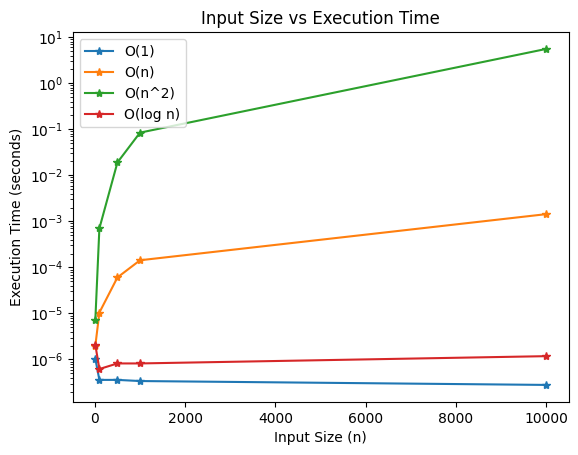

In [64]:
for col in df.columns[1:]:
    plt.plot(df["n"],df[col],marker="*",label=col)

plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Input Size vs Execution Time")
plt.legend()
plt.grid(False)
plt.yscale("log")
plt.show()

TASK 2 — Search Analysis

In [15]:
def linear_search(arr, key):
    for i in range(len(arr)):
        if arr[i] == key:
            return i
    return -1

def binary_search(arr, key):
    l, r = 0, len(arr)-1
    while l <= r:
        mid = (l+r)//2
        if arr[mid] == key:
            return mid
        elif arr[mid] < key:
            l = mid+1
        else:
            r = mid-1
    return -1


In [ ]:
def avg_time(func,arr,target,repeat=5):
    total=0
    for i in range(repeat):
        start= time.perf_counter()
        func(arr,target)
        total +=time.perf_counter() - start
    return total/repeat


sizes=[100,500,1000,5000,10000]

results=[]

for n in sizes:
    arr=random.sample(range(1,n*10),n)

    arr_sorted=sorted(arr)

    best_goal=arr[0]            
    avg_goal=arr[n // 2]        
    worst_goal=-1            

    Lbest=avg_time(linear_search, arr, best_goal)
    Lavg=avg_time(linear_search, arr, avg_goal)
    Lworst=avg_time(linear_search, arr, worst_goal)

    Bbest=avg_time(binary_search, arr_sorted, arr_sorted[n // 2]) 
    Bavg=avg_time(binary_search, arr_sorted, avg_goal)
    Bworst=avg_time(binary_search, arr_sorted, worst_goal)

    results.append([n,Lbest,Lavg,Lworst,Bbest,Bavg,Bworst])

In [17]:
df = pd.DataFrame(results, columns=[
    "n",
    "Linear Best", "Linear Avg", "Linear Worst",
    "Binary Best", "Binary Avg", "Binary Worst"
])

print("\nExecution Time Table:\n")
print(df)


Execution Time Table:

       n   Linear Best  Linear Avg  Linear Worst  Binary Best    Binary Avg  \
0    100  5.799928e-07    0.000001      0.000002     0.000001  4.399917e-07   
1    500  5.800044e-07    0.000005      0.000011     0.000001  7.399940e-07   
2   1000  3.599911e-07    0.000013      0.000025     0.000001  8.799951e-07   
3   5000  3.399909e-07    0.000064      0.000124     0.000001  1.160009e-06   
4  10000  8.200062e-07    0.000153      0.000386     0.000003  2.299994e-06   

   Binary Worst  
0  5.800044e-07  
1  7.200055e-07  
2  9.199954e-07  
3  1.179997e-06  
4  9.320001e-06  


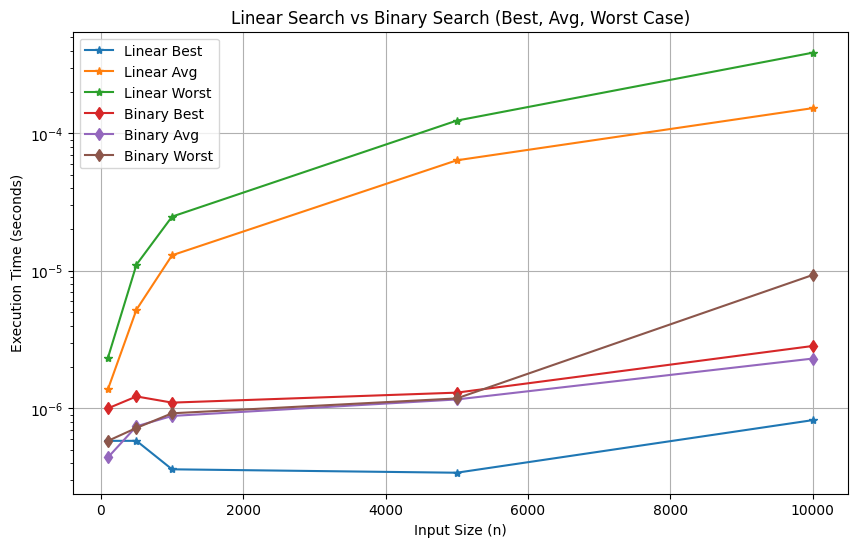

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(df["n"], df["Linear Best"], marker="*", label="Linear Best")
plt.plot(df["n"], df["Linear Avg"], marker="*", label="Linear Avg")
plt.plot(df["n"], df["Linear Worst"], marker="*", label="Linear Worst")

plt.plot(df["n"], df["Binary Best"], marker="d", label="Binary Best")
plt.plot(df["n"], df["Binary Avg"], marker="d", label="Binary Avg")
plt.plot(df["n"], df["Binary Worst"], marker="d", label="Binary Worst")

plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Linear Search vs Binary Search (Best, Avg, Worst Case)")
plt.legend()
plt.grid(True)

plt.yscale("log")
plt.show()

### Observation
- Binary search is significantly faster for large input.
- Linear search grows linearly with input size.
- Binary search requires sorted data.


TASK 3 — Recursion vs DP

In [ ]:
# Factorial (Recursive)
fact_count = 0

def factorial(n):
    global fact_count
    fact_count+=1

    if n==0 or n==1:
        return 1
    return n*factorial(n-1)

# Fibonacci (Naive Recursion)
fib_naivecount=0

def fib_naive(n):
    global fib_naivecount
    fib_naivecount += 1

    if n <= 1:
        return n
    return fib_naive(n - 1) + fib_naive(n - 2)

# Fibonacci (DP / Memoization)
fib_dpcount=0

def fib_dp(n, i=None):
    global fib_dpcount
    fib_dpcount+=1

    if i is None:
        i = {}

    if n in i:
        return i[n]

    if n <= 1:
        return n

    i[n] = fib_dp(n - 1, i) + fib_dp(n - 2, i)
    return i[n]


In [ ]:
def measure(func, n):
    start = time.perf_counter()
    value = func(n)
    end = time.perf_counter()
    return value, (end - start)


fact_inputs = [5, 10, 15, 20]
fib_inputs = [5, 10, 15, 20, 25, 30]  

results = []

# Factorial Results
for n in fact_inputs:
    fact_count = 0
    val, t = measure(factorial, n)

    results.append({
        "Algorithm": "Factorial (Recursion)",
        "n": n,
        "Value": val,
        "Function Calls": fact_count,
        "Time (sec)": t
    })

for n in fib_inputs:
    # Naive Fibonacci
    fib_naivecount = 0
    val1, t1 = measure(fib_naive, n)

    results.append({
        "Algorithm": "Fibonacci (Naive)",
        "n": n,
        "Value": val1,
        "Function Calls": fib_naivecount,
        "Time (sec)": t1
    })

    # DP Fibonacci
    fib_dpcount = 0
    val2, t2 = measure(lambda x: fib_dp(x, {}), n)

    results.append({
        "Algorithm": "Fibonacci (DP)",
        "n": n,
        "Value": val2,
        "Function Calls": fib_dpcount,
        "Time (sec)": t2})

In [42]:
df = pd.DataFrame(results)
print("\nTask 3 Table (Time + Calls):\n")
print(df)


Task 3 Table (Time + Calls):

                Algorithm   n                Value  Function Calls  Time (sec)
0   Factorial (Recursion)   5                  120               5    0.000003
1   Factorial (Recursion)  10              3628800              10    0.000002
2   Factorial (Recursion)  15        1307674368000              15    0.000003
3   Factorial (Recursion)  20  2432902008176640000              20    0.000003
4       Fibonacci (Naive)   5                    5              15    0.000003
5          Fibonacci (DP)   5                    5               9    0.000004
6       Fibonacci (Naive)  10                   55             177    0.000016
7          Fibonacci (DP)  10                   55              19    0.000003
8       Fibonacci (Naive)  15                  610            1973    0.000172
9          Fibonacci (DP)  15                  610              29    0.000006
10      Fibonacci (Naive)  20                 6765           21891    0.001256
11         Fibonacci 

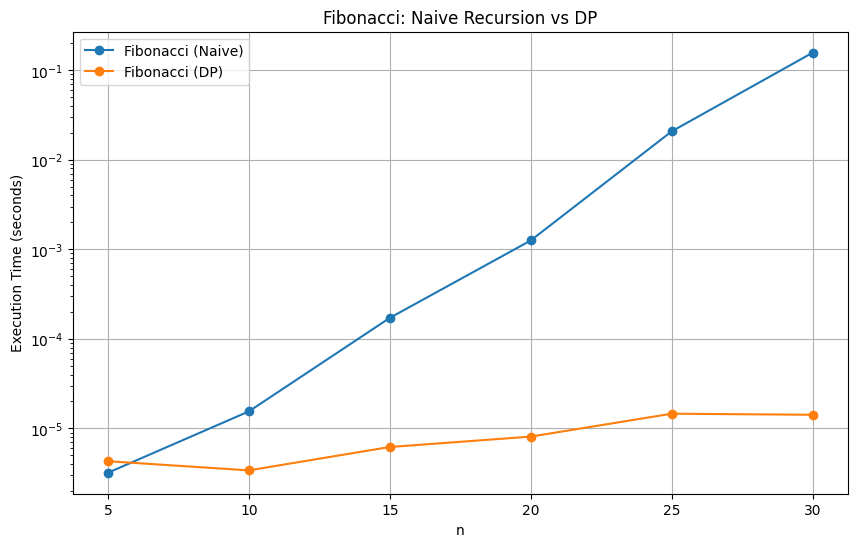

In [43]:
fib_df = df[df["Algorithm"].str.contains("Fibonacci")]

plt.figure(figsize=(10, 6))

for algo in fib_df["Algorithm"].unique():
    temp = fib_df[fib_df["Algorithm"] == algo]
    plt.plot(temp["n"], temp["Time (sec)"], marker="o", label=algo)

plt.xlabel("n")
plt.ylabel("Execution Time (seconds)")
plt.title("Fibonacci: Naive Recursion vs DP")
plt.legend()
plt.grid(True)

plt.yscale("log")   
plt.show()

### Observation
- Naive Fibonacci is very slow.
- Dynamic programming drastically reduces time.
- Recursive calls grow exponentially.


TASK 4 — Recurrence Simulation

In [ ]:
# Recurrence 1:
# T(n) = T(n/2) + n

count_1 = 0

def T1(n):
    global count_1
    count_1 += 1

    if n <= 1:
        return 1
    return T1(n // 2) + n


# Recurrence 2:
# T(n) = 2T(n/2) + n

count_2 = 0

def T2(n):
    global count_2
    count_2 += 1

    if n <= 1:
        return 1
    return 2 * T2(n // 2) + n


In [47]:
def measure(func, n):
    start = time.perf_counter()
    val = func(n)
    end = time.perf_counter()
    return val, end - start

In [58]:
sizes=[2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048,4096]

results=[]

for n in sizes:
    # T1 
    count_1 = 0
    val1, t1 = measure(T1, n)

    results.append({
        "Recurrence": "T(n) = T(n/2) + n",
        "n": n,
        "Value": val1,
        "Calls": count_1,
        "Time (sec)": t1
    })

    # T2
    count_2 = 0
    val2, t2 = measure(T2, n)

    results.append({
        "Recurrence": "T(n) = 2T(n/2) + n",
        "n": n,
        "Value": val2,
        "Calls": count_2,
        "Time (sec)": t2
    })

In [59]:
df = pd.DataFrame(results)
print("\nTask 4 Table:\n")
print(df)


Task 4 Table:

            Recurrence     n  Value  Calls    Time (sec)
0    T(n) = T(n/2) + n     2      3      0  1.400011e-06
1   T(n) = 2T(n/2) + n     2      4      0  1.099950e-06
2    T(n) = T(n/2) + n     4      7      0  6.000046e-07
3   T(n) = 2T(n/2) + n     4     12      0  6.000046e-07
4    T(n) = T(n/2) + n     8     15      0  7.000053e-07
5   T(n) = 2T(n/2) + n     8     32      0  7.000053e-07
6    T(n) = T(n/2) + n    16     31      0  8.000061e-07
7   T(n) = 2T(n/2) + n    16     80      0  8.000061e-07
8    T(n) = T(n/2) + n    32     63      0  9.000069e-07
9   T(n) = 2T(n/2) + n    32    192      0  1.000008e-06
10   T(n) = T(n/2) + n    64    127      0  1.099950e-06
11  T(n) = 2T(n/2) + n    64    448      0  1.300010e-06
12   T(n) = T(n/2) + n   128    255      0  1.300010e-06
13  T(n) = 2T(n/2) + n   128   1024      0  1.500011e-06
14   T(n) = T(n/2) + n   256    511      0  1.499953e-06
15  T(n) = 2T(n/2) + n   256   2304      0  1.700013e-06
16   T(n) = T(n

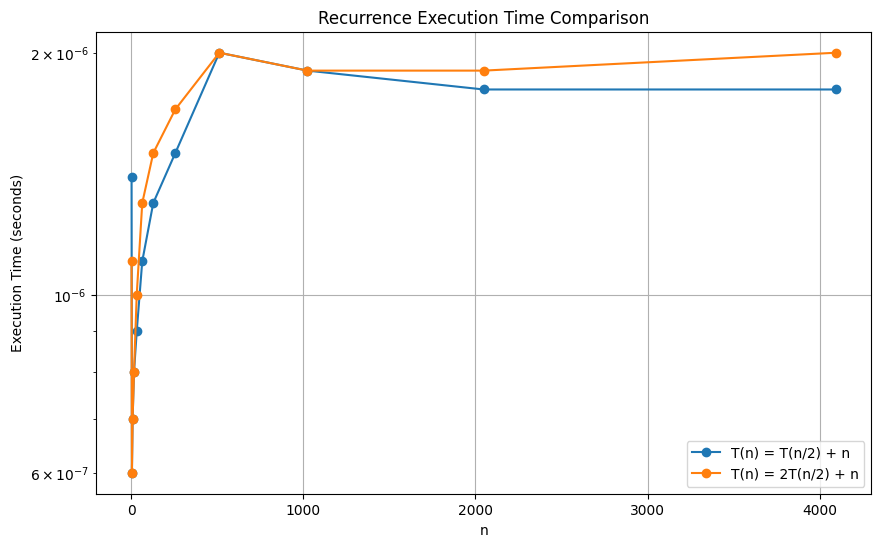

In [60]:
plt.figure(figsize=(10, 6))

for rec in df["Recurrence"].unique():
    temp = df[df["Recurrence"] == rec]
    plt.plot(temp["n"], temp["Time (sec)"], marker="o", label=rec)

plt.xlabel("n")
plt.ylabel("Execution Time (seconds)")
plt.title("Recurrence Execution Time Comparison")
plt.legend()
plt.grid(True)

plt.yscale("log")
plt.show()

### Observation
- T(n) = T(n/2) + n behaves like O(n)
- T(n) = 2T(n/2) + n behaves like O(n log n)
- Experimental results match theoretical complexity.
